# Step 3 - Seniority Labeling and Corpus Cleaning

                This notebook collapses LinkedIn experience levels into four bins, applies title-based
                overrides and backfills, builds normalized modeling text, and removes duplicate templates.


In [1]:
import os
import sys
from pathlib import Path

import pandas as pd

SRC_PATH = os.path.abspath("../src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

from linkedin_experiment.pipeline import build_labeling_outputs

outputs = build_labeling_outputs()
outputs


{'labeled': WindowsPath('D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM 129/Project/encoded-inequality/data/processed/linkedin_digital_tech_labeled.csv'),
 'labeled_only': WindowsPath('D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM 129/Project/encoded-inequality/data/processed/linkedin_digital_tech_labeled_only.csv'),
 'override_review': WindowsPath('D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM 129/Project/encoded-inequality/results/labeling/linkedin_digital_tech_seniority_override_review.csv'),
 'seniority_summary': WindowsPath('D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM 129/Project/encoded-inequality/results/labeling/linkedin_digital_tech_seniority_summary.csv'),
 'duplicate_summary': WindowsPath('D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM 129/Project/encoded-inequality/results/labeling/linkedin_digital_tech_duplicate_summary.csv'),
 'clean_entry': WindowsPath('D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM 129/Project/encoded-inequality/data/processed/linkedin_digital_tech_entry

In [2]:
summary = pd.read_csv("../results/labeling/linkedin_digital_tech_seniority_summary.csv")
duplicates = pd.read_csv("../results/labeling/linkedin_digital_tech_duplicate_summary.csv")
override_review = pd.read_csv("../results/labeling/linkedin_digital_tech_seniority_override_review.csv")
summary, duplicates, override_review.head(20)


(   seniority_final  seniority_source  rows
 0            entry  linkedin_primary  1082
 1            entry    title_backfill   138
 2            entry    title_override    37
 3       leadership  linkedin_primary    56
 4       leadership    title_backfill   656
 5       leadership    title_override  1578
 6              mid  linkedin_primary   370
 7              mid    title_backfill  1926
 8           senior  linkedin_primary  2121
 9           senior    title_backfill  2417
 10          senior    title_override   130,
                 metric  value
 0           rows_total  10511
 1  rows_kept_for_model   9622
 2     exact_duplicates    749
 3  template_duplicates    889,
         job_id                                             title  \
 0   3475933396                                  Senior Developer   
 1   3884425580                 Technical Product Manager - Cloud   
 2   3884429636      Senior Scientific Project Manager - Genomics   
 3   3884429764            Technical Pr

In [3]:
labeled = pd.read_csv("../data/processed/linkedin_digital_tech_labeled.csv")
labeled[
    [
        "job_id",
        "title",
        "raw_experience_level",
        "seniority_final",
        "seniority_source",
        "keep_for_model",
        "duplicate_group_id",
    ]
].head(20)


,job_id,title,raw_experience_level,seniority_final,seniority_source,keep_for_model,duplicate_group_id
0,133130219,Software Engineer,NaN,mid,title_backfill,True,NaN
1,175485704,Software Engineer,NaN,mid,title_backfill,True,NaN
2,2234533717,Full Stack Engineer,NaN,mid,title_backfill,True,NaN
3,2269442456,Computer Scientist,NaN,mid,title_backfill,True,NaN
4,3075721793,Architect/Project Manager,NaN,leadership,title_backfill,True,NaN
5,3169712432,Salesforce Vlocity Developer,NaN,mid,title_backfill,True,NaN
6,3245063922,Data Architect,NaN,mid,title_backfill,True,NaN
7,3366698309,Anaplan Developer,Mid-Senior level,senior,linkedin_primary,True,NaN
8,3398076960,Technical Product and IT Manager for Data Cent...,NaN,leadership,title_backfill,True,NaN
9,3475933396,Senior Developer,Associate,senior,title_override,True,NaN


## Report Visual Aids

These charts are built from the saved labeling outputs, so they can be run independently of the heavier cleaning pipeline.


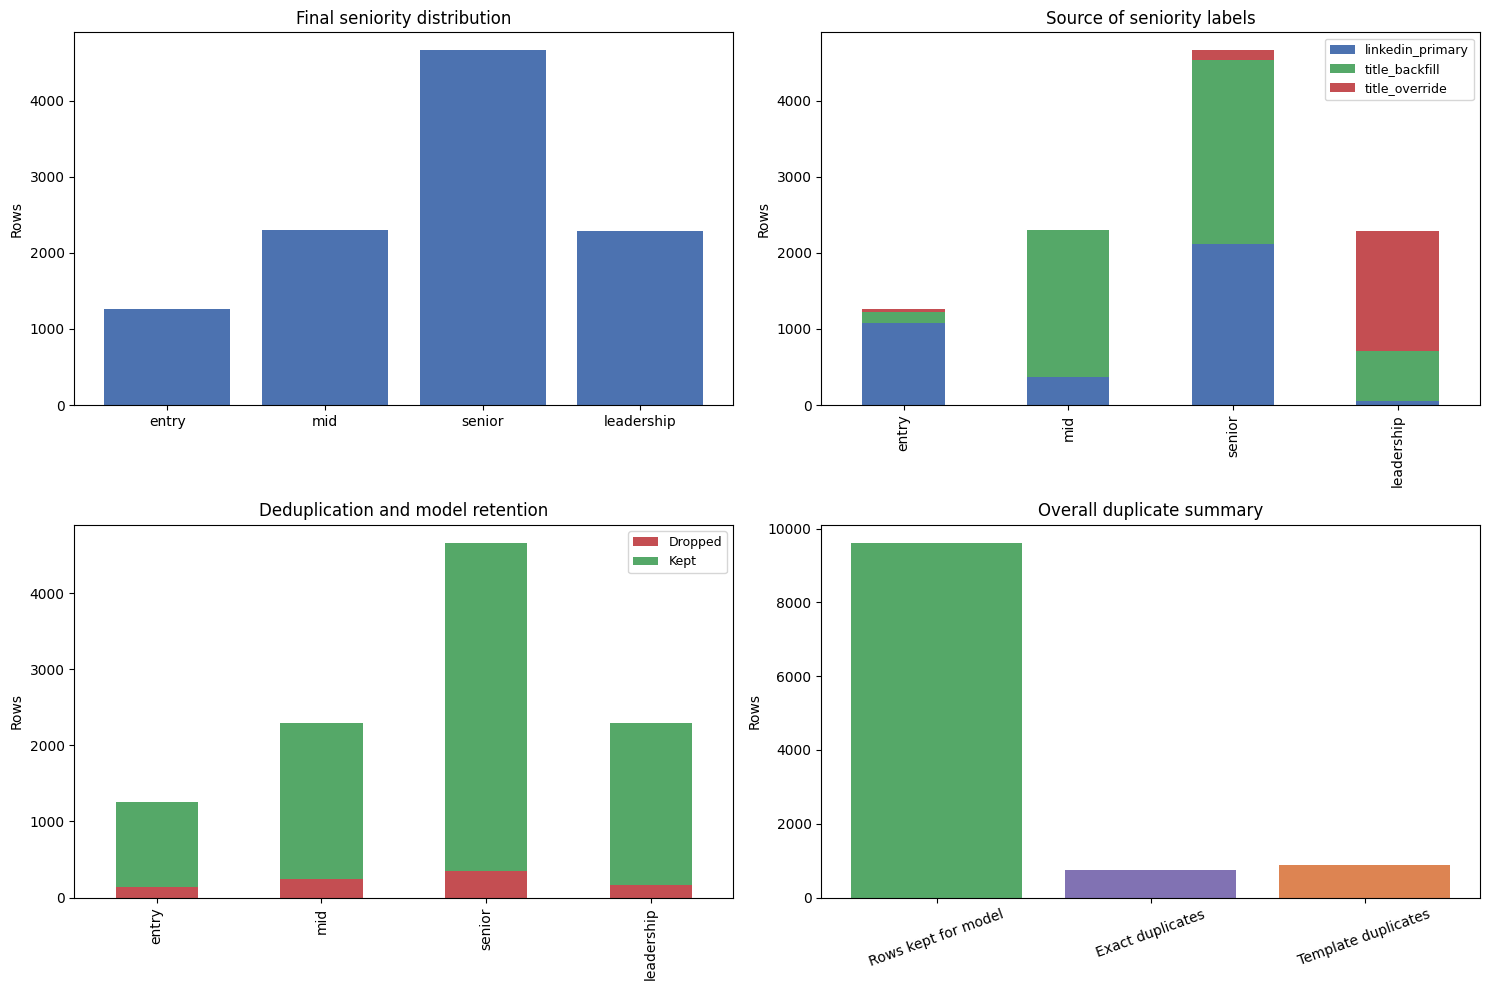

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

group_order = ["entry", "mid", "senior", "leadership"]
labels_dir = Path("../results/labeling")
processed_dir = Path("../data/processed")

summary = pd.read_csv(labels_dir / "linkedin_digital_tech_seniority_summary.csv")
duplicates = pd.read_csv(labels_dir / "linkedin_digital_tech_duplicate_summary.csv")
labeled = pd.read_csv(
    processed_dir / "linkedin_digital_tech_labeled.csv",
    usecols=["seniority_final", "keep_for_model"],
)

source_mix = (
    summary.pivot(index="seniority_final", columns="seniority_source", values="rows")
    .fillna(0)
    .reindex(group_order)
)
seniority_counts = labeled["seniority_final"].value_counts().reindex(group_order).fillna(0)
keep_mix = (
    labeled.groupby(["seniority_final", "keep_for_model"]).size().unstack(fill_value=0)
    .reindex(group_order)
    .rename(columns={False: "Dropped", True: "Kept"})
)
duplicate_metrics = duplicates.set_index("metric")["value"]
duplicate_plot = pd.Series(
    {
        "Rows kept for model": duplicate_metrics["rows_kept_for_model"],
        "Exact duplicates": duplicate_metrics["exact_duplicates"],
        "Template duplicates": duplicate_metrics["template_duplicates"],
    }
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].bar(seniority_counts.index, seniority_counts.values, color="#4c72b0")
axes[0, 0].set_title("Final seniority distribution")
axes[0, 0].set_ylabel("Rows")

source_mix.plot(kind="bar", stacked=True, ax=axes[0, 1], color=["#4c72b0", "#55a868", "#c44e52"])
axes[0, 1].set_title("Source of seniority labels")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Rows")
axes[0, 1].legend(title="", fontsize=9)

keep_mix.plot(kind="bar", stacked=True, ax=axes[1, 0], color=["#c44e52", "#55a868"])
axes[1, 0].set_title("Deduplication and model retention")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Rows")
axes[1, 0].legend(title="", fontsize=9)

axes[1, 1].bar(duplicate_plot.index, duplicate_plot.values, color=["#55a868", "#8172b3", "#dd8452"])
axes[1, 1].set_title("Overall duplicate summary")
axes[1, 1].set_ylabel("Rows")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plot_name = "Step 3 - Report Visual Aids"
plt.savefig(f"{plot_name}.png", dpi=300, bbox_inches="tight")
plt.show()
